## Uczenie maszynowe – zastosowania
### Zajęcia laboratoryjne
# 3. Regresja liniowa – zadanie

## Zadanie 3

### Część podstawowa (4 punkty)

Plik `fires_thefts.csv` zawiera rzeczywiste dane zebrane przez *U.S. Commission on Civil Rights*, przedstawiające liczbę pożarów w danej dzielnicy na tysiąc gospodarstw domowych (pierwsza kolumna) oraz liczbę włamań w tej samej dzielnicy na tysiąc mieszkańców (druga kolumna). 

Stwórz model (regresja liniowa) przewidujący liczbę włamań na podstawie liczby pożarów:
 * Oblicz parametry $\theta$ krzywej regresyjnej za pomocą metody gradientu prostego (*gradient descent*). Możesz wybrać wersję iteracyjną lub macierzową algorytmu.
 * Wykorzystując uzyskaną krzywą regresyjną przepowiedz liczbę włamań na tysiąc mieszkańców dla dzielnicy, w której występuje średnio 50, 100, 200 pożarów na tysiąc gospodarstw domowych.

intercept (theta0) = 16.995157
slope (theta1) = 1.313456
Prognoza dla 50 pozarow: 82.668 wlaman na 1000 mieszkancow
Prognoza dla 100 pozarow: 148.341 wlaman na 1000 mieszkancow
Prognoza dla 200 pozarow: 279.686 wlaman na 1000 mieszkancow


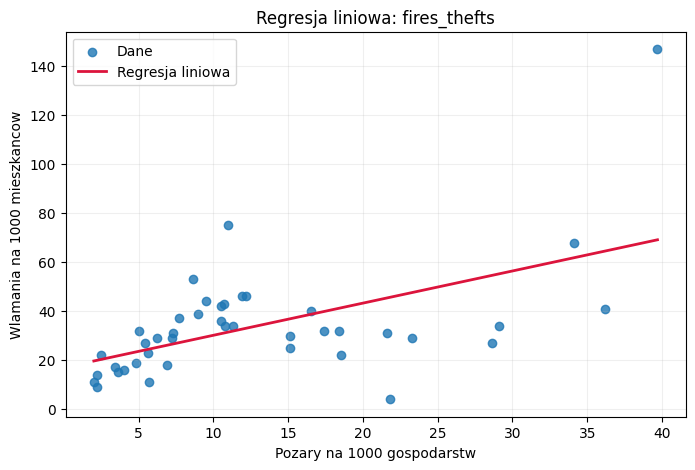

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

dataset = pd.read_csv("fires_thefts.csv", header=None, names=["fires", "thefts"])
fires_per_1000_households = dataset["fires"].to_numpy(dtype=float)
burglaries_per_1000_residents = dataset["thefts"].to_numpy(dtype=float)


def compute_cost(feature_matrix, target_values, parameters):
    residuals = feature_matrix @ parameters - target_values
    return (residuals @ residuals) / (2 * len(target_values))


def run_gradient_descent(
    feature_matrix, target_values, learning_rate=0.01, num_iterations=200
):
    parameters = np.zeros(feature_matrix.shape[1], dtype=float)
    cost_history = np.zeros(num_iterations, dtype=float)
    sample_count = len(target_values)

    for step_idx in range(num_iterations):
        residuals = feature_matrix @ parameters - target_values
        gradient = (feature_matrix.T @ residuals) / sample_count
        parameters = parameters - learning_rate * gradient
        cost_history[step_idx] = compute_cost(feature_matrix, target_values, parameters)

    return parameters, cost_history


raw_feature_matrix = np.c_[
    np.ones_like(fires_per_1000_households), fires_per_1000_households
]

parameters, _ = run_gradient_descent(
    raw_feature_matrix,
    burglaries_per_1000_residents,
    learning_rate=0.001,
    num_iterations=100000,
)

intercept = parameters[0]
slope = parameters[1]

print(f"intercept (theta0) = {intercept:.6f}")
print(f"slope (theta1) = {slope:.6f}")

for fires_value in [50, 100, 200]:
    predicted_burglaries = intercept + slope * fires_value
    print(
        f"Prognoza dla {fires_value} pozarow: {predicted_burglaries:.3f} wlaman na 1000 mieszkancow"
    )

fires_line = np.linspace(
    fires_per_1000_households.min(), fires_per_1000_households.max(), 200
)
predicted_line = intercept + slope * fires_line

plt.figure(figsize=(8, 5))
plt.scatter(
    fires_per_1000_households, burglaries_per_1000_residents, alpha=0.8, label="Dane"
)
plt.plot(
    fires_line, predicted_line, color="crimson", linewidth=2, label="Regresja liniowa"
)
plt.xlabel("Pozary na 1000 gospodarstw")
plt.ylabel("Wlamania na 1000 mieszkancow")
plt.title("Regresja liniowa: fires_thefts")
plt.grid(alpha=0.2)
plt.legend()
plt.show()

### Część zaawansowana (2 punkty)

Dla różnych wartości długości kroku $\alpha \in \{ 0.001, 0.01 , 0.1 \}$ stwórz wykres, który zilustruje progresję wartości $J(\theta)$ dla pierwszych 200 króków algorytmu gradientu prostego:
 * Oś $x$ wykresu to kolejne kroki algorytmu – od 0 do 200.
 * Oś $y$ wykresu to wartosci $J(\theta)$.
 * Wykres powinien skłądać się z trzech krzywych:
   1. dla $\alpha = 0.001$
   2. dla $\alpha = 0.01$
   3. dla $\alpha = 0.1$

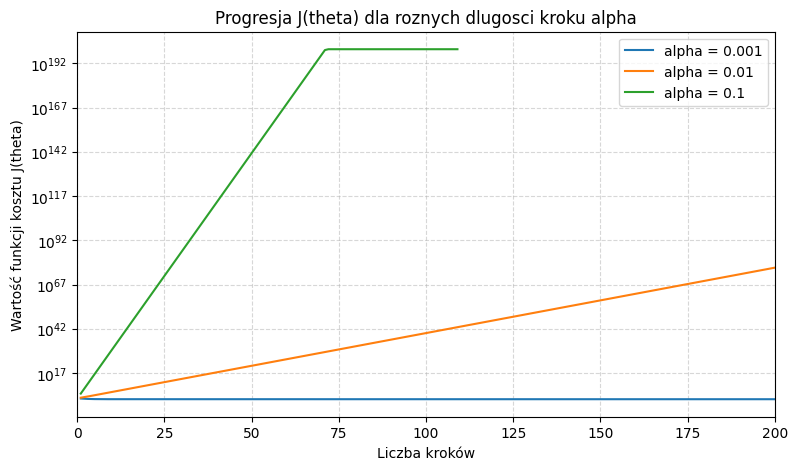

In [ ]:
import warnings
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

learning_rate_values = [0.001, 0.01, 0.1]
max_steps = 200

plt.figure(figsize=(9, 5))
for current_learning_rate in learning_rate_values:
    _, optimization_cost_history = run_gradient_descent(
        raw_feature_matrix,
        burglaries_per_1000_residents,
        learning_rate=current_learning_rate,
        num_iterations=max_steps,
    )

    # matplotlib inf issues (values for alpha = 0.1 -> inf)
    safe_history = np.clip(optimization_cost_history, a_min=None, a_max=1e200)
    safe_history[
        np.isinf(optimization_cost_history) | np.isnan(optimization_cost_history)
    ] = np.nan

    step_numbers = np.arange(1, max_steps + 1)
    plt.plot(step_numbers, safe_history, label=f"alpha = {current_learning_rate}")

plt.xlabel("Liczba kroków")
plt.ylabel("Wartosc funkcji kosztu J(theta)")
plt.title("Progresja J(theta) dla roznych dlugosci kroku alpha")

plt.yscale("log")

plt.xlim(0, max_steps)
plt.grid(alpha=0.5, linestyle="--")
plt.legend()
plt.show()